In [37]:
# Uncomment these in a fresh notebook environment.
#%pip install -r ../requirements.txt
#%pip install -e ..

In [38]:
from marl_tsc.simulation_generator import SimulationGenerator, DEFAULT_TRAFFIC_LIGHT_IDS
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions
from pathlib import Path
import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = 4
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"

traffic_light_ids = list(DEFAULT_TRAFFIC_LIGHT_IDS)


In [39]:
# Compare policy results
def print_comparison_table(rows):
    columns = [
        "Policy",
        "Episodes",
        "Mean total reward",
        "Mean local queue",
        "Total completed steps",
        "Mean switches / episode",
    ]

    def format_value(value):
        if isinstance(value, float):
            return f"{value:.3f}"
        return str(value)

    widths = {column: len(column) for column in columns}
    for row in rows:
        for column in columns:
            widths[column] = max(widths[column], len(format_value(row.get(column, ""))))

    header = " | ".join(column.ljust(widths[column]) for column in columns)
    separator = "-+-".join("-" * widths[column] for column in columns)
    print(header)
    print(separator)
    for row in rows:
        print(" | ".join(format_value(row.get(column, "")).ljust(widths[column]) for column in columns))

## 1. Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change these values first when you want a different learning problem.


In [40]:
EPISODE_STEPS = 600  # The number of actions/steps the RL agent takes per episode
SECONDS_PER_ACTION = 5  # Matches the step logic in your SumoTrafficEnv
# The actual duration in SUMO seconds that the RL agent will experience
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION

# To ensure continuous flow, spawn vehicles for 20% longer than the simulation runs.
# This guarantees that the network never empties out or hits ACT = 0.
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)

NUM_EPISODES = 30
EVALUATION_EPISODES = 5
TOTAL_TIMESTEPS = 75_000
MIN_GREEN_SECONDS = 10
SWITCH_PENALTY = 2.0

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,  # Extends past the simulation end!
    trip_period=2,                    # Steady stream: 1 car every 2 seconds
    seed=42,
)

paths = generator.generate_all()
print(f"Generated continuous flow configuration: {paths.config_file}")
print(f"Simulation Horizon: {SIMULATION_DURATION}s | Traffic Spawning Until: {TRAFFIC_SPAWN_DURATION}s")
print("Traffic-light agents:", traffic_light_ids)

Generated continuous flow configuration: C:\Code\marl-tsc\outputs\config.sumocfg
Simulation Horizon: 3000s | Traffic Spawning Until: 3600s
Traffic-light agents: ['B1', 'B2', 'C1', 'C2']


## 2. Run the simple baselines

Random and fixed-time are useful sanity checks before training. They use the same environment and the same evaluation seeds as the learned policies.


In [41]:
def get_evaluation_results(policy):
    return evaluate_policy(
        config_file=paths.config_file,
        traffic_light_ids=traffic_light_ids,
        policy=policy,
        episodes=EVALUATION_EPISODES,
        max_steps=EPISODE_STEPS,
        seed=42,
        env_kwargs={
            "green_phase_count": GREEN_PHASE_COUNT,
            "min_green_seconds": MIN_GREEN_SECONDS,
            "seconds_per_action": SECONDS_PER_ACTION,
            "switch_penalty": SWITCH_PENALTY,
        },
    )

## 3. Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.


### PPO

[PPO] Step 2400 | Episode Return: -82.86
[PPO] Step 2400 | Episode Return: -84.14
[PPO] Step 2400 | Episode Return: -88.26
[PPO] Step 2400 | Episode Return: -86.67
[PPO] Step 4800 | Episode Return: -84.01
[PPO] Step 4800 | Episode Return: -82.85
[PPO] Step 4800 | Episode Return: -87.25
[PPO] Step 4800 | Episode Return: -85.04
[PPO] Step 7200 | Episode Return: -83.25
[PPO] Step 7200 | Episode Return: -91.86
[PPO] Step 7200 | Episode Return: -91.51
[PPO] Step 7200 | Episode Return: -91.14
[PPO] Step 9600 | Episode Return: -80.06
[PPO] Step 9600 | Episode Return: -84.31
[PPO] Step 9600 | Episode Return: -81.06
[PPO] Step 9600 | Episode Return: -86.60
[PPO] Step 12000 | Episode Return: -83.05
[PPO] Step 12000 | Episode Return: -82.02
[PPO] Step 12000 | Episode Return: -86.57
[PPO] Step 12000 | Episode Return: -91.96
[PPO] Step 14400 | Episode Return: -83.56
[PPO] Step 14400 | Episode Return: -80.69
[PPO] Step 14400 | Episode Return: -86.99
[PPO] Step 14400 | Episode Return: -81.96
[PPO] St

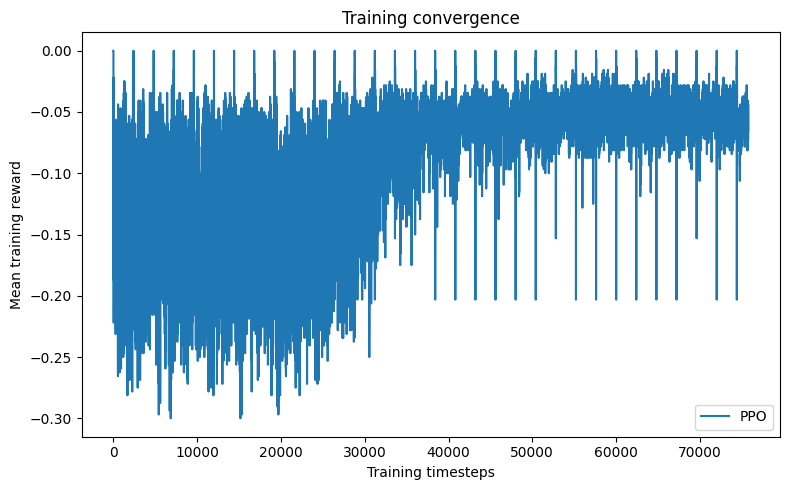

In [42]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS,
                "switch_penalty": SWITCH_PENALTY },
)

fig, ax = plot_training_histories(ppo_history)
plt.show()

### MAPPO

[MAPPO] Episode 1 | Return: -85.74 | Total Steps: 600
[MAPPO] Episode 2 | Return: -86.86 | Total Steps: 1200
[MAPPO] Episode 3 | Return: -82.45 | Total Steps: 1800
[MAPPO] Episode 4 | Return: -88.44 | Total Steps: 2400
[MAPPO] Episode 5 | Return: -85.18 | Total Steps: 3000
[MAPPO] Episode 6 | Return: -89.51 | Total Steps: 3600
[MAPPO] Episode 7 | Return: -91.22 | Total Steps: 4200
[MAPPO] Episode 8 | Return: -88.26 | Total Steps: 4800
[MAPPO] Episode 9 | Return: -86.88 | Total Steps: 5400
[MAPPO] Episode 10 | Return: -86.34 | Total Steps: 6000
[MAPPO] Episode 11 | Return: -84.53 | Total Steps: 6600
[MAPPO] Episode 12 | Return: -88.27 | Total Steps: 7200
[MAPPO] Episode 13 | Return: -84.29 | Total Steps: 7800
[MAPPO] Episode 14 | Return: -84.39 | Total Steps: 8400
[MAPPO] Episode 15 | Return: -86.52 | Total Steps: 9000
[MAPPO] Episode 16 | Return: -80.38 | Total Steps: 9600
[MAPPO] Episode 17 | Return: -84.63 | Total Steps: 10200
[MAPPO] Episode 18 | Return: -85.21 | Total Steps: 10800


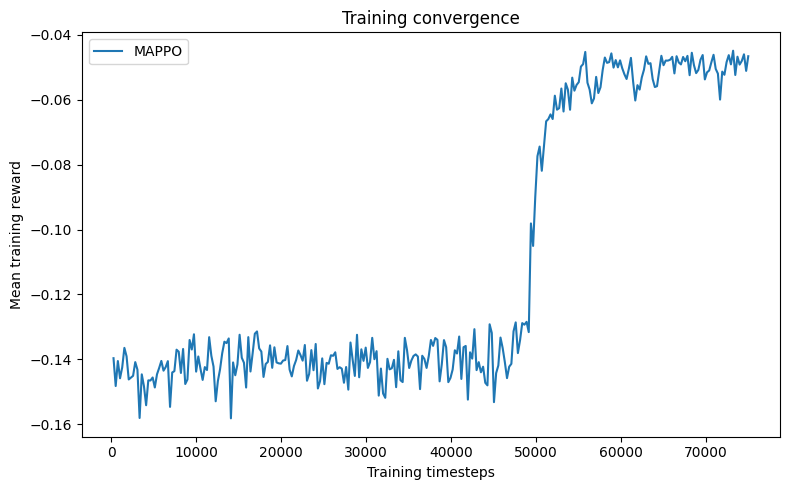

In [43]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": MIN_GREEN_SECONDS,
                "switch_penalty": SWITCH_PENALTY },
)

fig, ax = plot_training_histories(mappo_history)
plt.show()

## 4. Evaluate all policies on the same seeds

The final comparison table keeps the baseline runs and adds the shared PPO and MAPPO policies on the same evaluation seeds.


In [44]:
policies = {"Random":random_actions,
           "Fixed-Time":fixed_time_actions,
           "Shared PPO":ppo_model,
           "MAPPO":mappo_model}

policy_results = {}

for name, policy in policies.items():
    print(f"Evaluating {name} model")
    policy_result = get_evaluation_results(policy)
    policy_results[name] = policy_result

Evaluating Random model
Finished Evaluation Episode 1/5 - Total Reward: -329.19
Finished Evaluation Episode 2/5 - Total Reward: -342.04
Finished Evaluation Episode 3/5 - Total Reward: -330.86
Finished Evaluation Episode 4/5 - Total Reward: -338.71
Finished Evaluation Episode 5/5 - Total Reward: -330.69
Evaluating Fixed-Time model
Finished Evaluation Episode 1/5 - Total Reward: -1649.09
Finished Evaluation Episode 2/5 - Total Reward: -1644.24
Finished Evaluation Episode 3/5 - Total Reward: -1647.21
Finished Evaluation Episode 4/5 - Total Reward: -1633.16
Finished Evaluation Episode 5/5 - Total Reward: -1634.59
Evaluating Shared PPO model
Finished Evaluation Episode 1/5 - Total Reward: -112.35
Finished Evaluation Episode 2/5 - Total Reward: -111.45
Finished Evaluation Episode 3/5 - Total Reward: -110.76
Finished Evaluation Episode 4/5 - Total Reward: -112.42
Finished Evaluation Episode 5/5 - Total Reward: -111.21
Evaluating MAPPO model
Finished Evaluation Episode 1/5 - Total Reward: -114

In [45]:
# Compare all results
comparison_rows = []

for name, result in policy_results.items():
    comparison_rows.append({
        "Policy": name,
        "Episodes": result["episodes"],
        "Mean total reward": result["mean_total_reward"],
        "Mean local queue": result["mean_local_queue"],
        "Total completed steps": result["total_completed_steps"],
        "Mean switches / episode": result["mean_switches_per_episode"]
    })

print_comparison_table(comparison_rows)

Policy     | Episodes | Mean total reward | Mean local queue | Total completed steps | Mean switches / episode
-----------+----------+-------------------+------------------+-----------------------+------------------------
Random     | 5        | -334.298          | 0.538            | 3000                  | 1025.400               
Fixed-Time | 5        | -1641.658         | 5.844            | 3000                  | 1196.000               
Shared PPO | 5        | -111.640          | 0.462            | 3000                  | 4.000                  
MAPPO      | 5        | -115.075          | 0.479            | 3000                  | 0.000                  
